## How Good Is Your Model?

- **Classification Metrics:**
    - One way to measure model performance is through **accuracy**, which is the fraction of correctly classified samples. However, accuracy is not always the most reliable metric, especially when dealing with imbalanced datasets.

- **Class Imbalance Example:**
    - Consider the example of **email classification** where 99% of emails are real, and only 1% are spam.
    - If we build a classifier that predicts *all* emails as real, it will be 99% accurate.
        - This would give the illusion of a "good" model, but the model completely fails to detect spam emails, which is the original purpose of the classification.
        - Therefore, relying solely on accuracy can be misleading in cases where there is a class imbalance.

- **Diagnosing Classification Predictions:**
    - A **Confusion Matrix** is used to evaluate the performance of a classification model by showing the number of true positives (TP), true negatives (TN), false positives (FP), and false negatives (FN).
    
    ![cm](https://github.com/goodboychan/goodboychan.github.io/blob/main/_notebooks/image/confusion_matrix.png?raw=1)

    - **Accuracy**: The proportion of correctly predicted instances.

    - **Precision (Positive Predictive Value)**: The proportion of true positive predictions among all positive predictions.

    - **Recall (Sensitivity, True Positive Rate, Hit Rate)**: The proportion of actual positives correctly identified by the model.

    - **F1 Score**: The harmonic mean of precision and recall. This metric balances the trade-off between precision and recall.
    
    - **High Precision**: Indicates that not many legitimate emails are incorrectly predicted as spam.
    - **High Recall**: Indicates that most of the spam emails are correctly identified by the model.

By using these metrics, we can better assess the performance of a classification model, especially in scenarios where accuracy alone does not provide a complete picture.

### Metrics for Classification

Accuracy alone does not always provide a full picture of a model's performance. In this exercise, you will explore more meaningful ways to evaluate the performance of binary classifiers by calculating a confusion matrix and generating a classification report.

In the video, you may have noticed that the classification report included three main metrics—precision, recall, and F1-score—along with an additional column called "support." The support value represents the number of samples in each class (true responses), indicating how many instances of a specific class (such as Republicans or Democrats) are present in the test dataset. Precision, recall, and F1-score, on the other hand, provide performance metrics for each class individually.

For this exercise, you will use the [PIMA Indians Diabetes Dataset](https://www.kaggle.com/uciml/pima-indians-diabetes-database) from the UCI Machine Learning Repository. The objective is to predict whether a given female patient is at risk of developing diabetes based on attributes such as BMI, age, and the number of pregnancies. This is a binary classification problem, where a target value of 0 indicates the patient does not have diabetes, and a target value of 1 indicates the patient does have diabetes. The dataset has already been preprocessed to handle any missing values, as demonstrated in previous chapters.

#### Preprocess

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Mounted at /content/drive


In [ ]:
diabete_csv = '/content/drive/MyDrive/Colab Notebooks/UCI/UCI_425.07_Big_Data_Analytics/Assignments/Dataset/diabetes.csv'
df = pd.read_csv(diabete_csv)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [ ]:
df.iloc[:-10,:3]

,Pregnancies,Glucose,BloodPressure
0,2,138,62
1,0,84,82
2,0,145,0
3,0,135,68
4,1,139,62
...,...,...,...
1985,0,131,88
1986,6,104,74
1987,3,148,66
1988,4,120,68


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Create training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Instantiate a k-NN classifier: knn
knn = KNeighborsClassifier(n_neighbors=6)

# Fit the classifier to the training data
knn.fit(X_train, y_train)

# Predict the labels of the test data: y_pred
y_pred = knn.predict(X_test)

# Generate the confusion matrix and classification report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[473  50]
 [128 149]]
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       523
           1       0.75      0.54      0.63       277

    accuracy                           0.78       800
   macro avg       0.77      0.72      0.73       800
weighted avg       0.77      0.78      0.77       800



## Logistic regression and the ROC curve
- Logistic regression for binary classification
    - Logistic regression outputs probabilities
    - If the probability is greater than 0.5:
        - The data is labeled '1'
    - If the probability is less than 0.5:
        - The data is labeled '0'
- Probability thresholds
    - By default, logistic regression threshold = 0.5
    - Not specific to logistic regression
        - k-NN classifiers also have thresholds
- ROC curves (Receiver Operating Characteristic curve)
![roc](https://github.com/goodboychan/goodboychan.github.io/blob/main/_notebooks/image/roc.png?raw=1)

### Building a Logistic Regression Model

Now it’s time to build your first logistic regression model! As Hugo demonstrated in the video, scikit-learn simplifies the process of trying different models, thanks to its consistent workflow. The Train-Test-Split/Instantiate/Fit/Predict approach is applicable to all types of classifiers and regressors, which scikit-learn refers to as 'estimators.' You will now apply this process to train a logistic regression model on the same dataset used in the previous exercise. Will it perform better than the k-NN model? The only way to know is to give it a try!

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Create the classifier: logreg
logreg = LogisticRegression(max_iter=1000)

# Fit the classifier to the training data
logreg.fit(X_train, y_train)

# Predict the labels of the test set: y_pred
y_pred = logreg.predict(X_test)

# Compute and print the confusion matrix and classification report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[471  52]
 [119 158]]
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       523
           1       0.75      0.57      0.65       277

    accuracy                           0.79       800
   macro avg       0.78      0.74      0.75       800
weighted avg       0.78      0.79      0.78       800



### Plotting an ROC Curve

Well done on completing the previous exercise – you’ve added a valuable classifier to your toolkit!

While classification reports and confusion matrices are excellent for quantitatively assessing model performance, ROC curves offer a visual way to evaluate models. As demonstrated in the video, many classifiers in scikit-learn come with a `.predict_proba()` method, which gives the probability of a sample belonging to each class. After building your logistic regression model, you'll now assess its performance by plotting an ROC curve. This will give you a chance to use the `.predict_proba()` method and understand how it works in evaluating your model’s output.

Text(0.5, 1.0, 'ROC Curve')

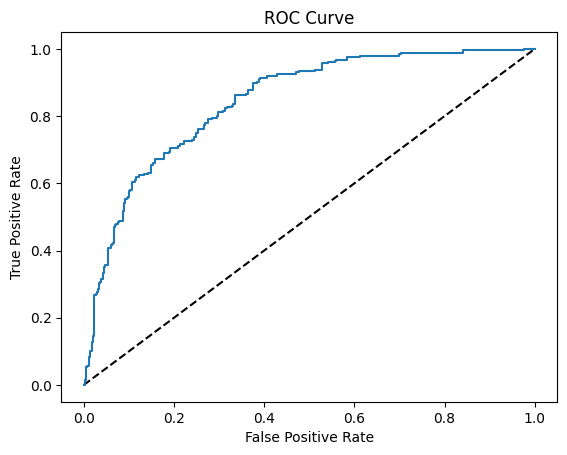

In [ ]:
from sklearn.metrics import roc_curve

# Compute predicted probabilities: y_pred_prob
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

# Generate ROC curve values: fpr, tpr, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Plot ROC curve
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

### Precision-recall Curve
When looking at your ROC curve, you may have noticed that the y-axis (True positive rate) is also known as recall. Indeed, in addition to the ROC curve, there are other ways to visually evaluate model performance. One such way is the precision-recall curve, which is generated by plotting the precision and recall for different thresholds. As a reminder, precision and recall are defined as:
$$ \text{Precision} = \dfrac{TP}{TP + FP} \\
   \text{Recall} = \dfrac{TP}{TP + FN}$$
   Study the precision-recall curve. Note that here, the class is positive (1) if the individual has diabetes.

Text(0.5, 1.0, 'Precision / Recall plot')

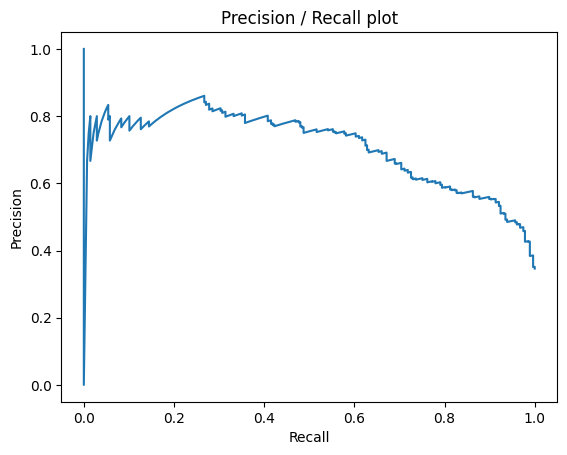

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision / Recall plot')

## Area Under the ROC Curve (AUC)

- A larger area under the ROC curve indicates a better-performing model.

### AUC Calculation

Let’s consider a binary classifier that is essentially making random predictions. In this case, the model would be correct about 50% of the time. The corresponding ROC curve would form a diagonal line where the True Positive Rate (TPR) and False Positive Rate (FPR) are identical throughout. The area under this ROC curve (AUC) would be 0.5, which is essentially equivalent to random guessing.

The AUC is a helpful metric to assess model performance, as discussed by Hugo in the video. If the AUC is greater than 0.5, it indicates that your model is performing better than random guessing, which is a positive outcome.

In this exercise, you will calculate AUC scores using the `roc_auc_score()` function from `sklearn.metrics`. You will also apply cross-validation to evaluate the performance of your model on the diabetes dataset.

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

# Compute predicted probabilites: y_pred_prob
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

# Compute and print AUC score
print("AUC: {}".format(roc_auc_score(y_test, y_pred_prob)))

# Compute cross-validated AUC scores: cv_auc
cv_auc = cross_val_score(logreg, X, y, cv=5, scoring='roc_auc')

# Print list of AUC scores
print("AUC scores computed using 5-fold cross-validation: {}".format(cv_auc))

AUC: 0.8437092309710018
AUC scores computed using 5-fold cross-validation: [0.81951653 0.85345952 0.8572618  0.78107741 0.8614639 ]


## Hyperparameter Tuning

- **Linear Regression**: Choosing the right model parameters.
- **Ridge/Lasso Regression**: Selecting the optimal value for alpha (a regularization parameter).
- **k-Nearest Neighbors (k-NN)**: Determining the appropriate number of neighbors (n_neighbors).

### What are Hyperparameters?

Hyperparameters are values that you set before training a model, and they are not learned from the data. For example, in Ridge and Lasso regression, the alpha value controls the strength of regularization, and in k-NN, the number of neighbors (k) is a key parameter. These hyperparameters influence the model’s performance, but they are not automatically determined by fitting the model.

### How to Choose the Right Hyperparameters

1. **Try different values** for each hyperparameter (e.g., test various alpha values or k values).
2. **Fit the model separately** for each set of hyperparameters.
3. **Evaluate how well each hyperparameter set performs** by comparing results.
4. **Select the best-performing hyperparameter combination** based on model evaluation.
5. **Use cross-validation** to ensure a robust and unbiased evaluation of each hyperparameter combination.

### Grid Search Cross-Validation

Grid search cross-validation is a common method for hyperparameter tuning. It systematically tests a range of hyperparameter values and uses cross-validation to assess which combination produces the best performance. This approach ensures that you’re selecting the most optimal set of hyperparameters for your model.

### Hyperparameter tuning with GridSearchCV
Like the alpha parameter of lasso and ridge regularization that you saw earlier, logistic regression also has a regularization parameter: $C$. $C$ controls the inverse of the regularization strength, and this is what you will tune in this exercise. A large $C$ can lead to an overfit model, while a small $C$ can lead to an underfit model.

The hyperparameter space for the regularization parameter \(C\) has already been set up for you. Your task is to use **GridSearchCV** along with **logistic regression** to determine the optimal value of \(C\) within this hyperparameter space.

You might be wondering why you aren’t asked to split the data into training and test sets. That’s a great question! In this exercise, the focus is on understanding how to set up the hyperparameter grid and perform grid-search cross-validation. In a real-world scenario, you would definitely want to split your data into training and testing sets for model evaluation, and you will learn how to do that in the upcoming video.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Setup the hyperparameter grid
c_space = np.logspace(-5, 8, 15)
param_grid = {'C':c_space}

# Instantiate a logistic regression classifier: logreg
logreg = LogisticRegression(max_iter=1000)

# Instantiate the GridSearchCV object: logreg_cv
logreg_cv = GridSearchCV(logreg, param_grid, cv=5)

# Fit it to the data
logreg_cv.fit(X, y)

# Print the tuned parameters and score
print("Tuned Logistic Regression Parameters: {}".format(logreg_cv.best_params_))
print("Best score is {}".format(logreg_cv.best_score_))

Tuned Logistic Regression Parameters: {'C': np.float64(3.727593720314938)}
Best score is 0.78


### Hyperparameter Tuning with RandomizedSearchCV

When dealing with a large hyperparameter space and multiple hyperparameters, **GridSearchCV** can become computationally expensive as it evaluates every possible combination. An alternative approach to this is **RandomizedSearchCV**, where instead of testing every possible hyperparameter combination, a fixed number of settings are randomly sampled from specified probability distributions. This allows you to explore a wide range of hyperparameters more efficiently.

In this exercise, you will practice using **RandomizedSearchCV** and see how it works in action.

Additionally, you'll be introduced to a new model: the **Decision Tree**. There's no need to worry about the underlying details of how the model works at this stage. Like other models such as k-NN, linear regression, and logistic regression, decision trees in **scikit-learn** come with `.fit()` and `.predict()` methods that you can use in the same way as the previous models. Decision trees have several hyperparameters that can be tuned, such as `max_features`, `max_depth`, and `min_samples_leaf`, making them a perfect candidate for **RandomizedSearchCV**.

In [ ]:
from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

# Setup the parameters and distributions to sample from: param_dist
param_dist = {
    "max_depth": [3, None],
    "max_features": randint(1, 9),
    "min_samples_leaf": randint(1, 9),
    "criterion": ["gini", "entropy"],
}

# Instantiate a Decision Tree classifier: tree
tree = DecisionTreeClassifier()

# Instantiate the RandomizedSearchCV object: tree_cv
tree_cv = RandomizedSearchCV(tree, param_dist, cv=5)

# Fit it to the data
tree_cv.fit(X, y)

# Print the tuned parameters and score
print("Tuned Decision Tree Parameters: {}".format(tree_cv.best_params_))
print("Best score is {}".format(tree_cv.best_score_))

Tuned Decision Tree Parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': 4, 'min_samples_leaf': 1}
Best score is 0.9945


## Hold-out Set for Final Evaluation

- The key question is: **How well can the model perform on data it has never seen before?**
- It is not ideal to use **all** the data for cross-validation, as doing so can lead to overfitting and may not provide an accurate measure of model performance on unseen data.
- The correct approach is to **split the data** into a **training set** and a **hold-out set** right from the start.
- Then, you can perform **grid search cross-validation** on the training set to find the best hyperparameters.
- After tuning the model, you evaluate its performance on the hold-out set to ensure it generalizes well.

### Hold-out Set in Practice I: Classification

In this exercise, you will practice evaluating a model with tuned hyperparameters using a hold-out set. The **feature array** (`X`) and the **target variable array** (`y`) from the diabetes dataset have already been pre-loaded for you.

Along with the **C** hyperparameter, logistic regression also has a **'penalty'** hyperparameter, which specifies whether to apply **'l1'** or **'l2'** regularization. Your task is to:
1. Create a **hold-out set**.
2. Tune the **'C'** and **'penalty'** hyperparameters of a logistic regression classifier using **GridSearchCV** on the training set.
3. Once the model is tuned, evaluate its performance on the hold-out set.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

# Create the hyperparameter grid
c_space = np.logspace(-5, 8, 15)
param_grid = {'C': c_space, 'penalty': ['l1', 'l2']}

# Instantiate the logistic regression classifier: logreg
logreg = LogisticRegression(max_iter=1000, solver='liblinear')

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Instantiate the GridSearchCV object: logreg_cv
logreg_cv = GridSearchCV(logreg, param_grid, cv=5)

# Fit it to the training data
logreg_cv.fit(X_train, y_train)

# Print the optimal parameters and best score
print("Tuned Logistic Regression Parameter: {}".format(logreg_cv.best_params_))
print("Tuned Logistic Regression Accuracy: {}".format(logreg_cv.best_score_))

Tuned Logistic Regression Parameter: {'C': np.float64(3.727593720314938), 'penalty': 'l1'}
Tuned Logistic Regression Accuracy: 0.7658333333333334
